In [2]:
# %% Imports and config
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


# --- CONFIG ---
BATCH_SIZE = 256
EPOCHS = 25
LEARNING_RATE = 1e-5
KFOLDS = 5
TEST_SPLIT = 0.2
SEED = 217

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from torch.utils.data import Dataset
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import torch

class TimeSeriesDataset(Dataset):
    def __init__(self, csv_files, step=1, input_range=(-1, 1), target_range=(-1, 1)):
        self.data = []
        self.target = []

        # Debug info
        print(f"📂 Processing {len(csv_files)} files: {csv_files}")
        if not csv_files:
            raise ValueError("❌ No CSV files provided.")

        for file in csv_files:
            df = pd.read_csv(file)
            if df.shape[1] < 4:
                raise IndexError(f"❌ {file} has less than 4 columns.")

            data = df.iloc[::step, [0, 1, 2]].values.astype(float)  # time, value, next_time
            target = df.iloc[::step, 3].values.astype(float)       # next_value

            self.data.append(data)
            self.target.append(target)

        # Concatenate everything into single numpy arrays
        self.data = np.concatenate(self.data, axis=0)
        self.target = np.concatenate(self.target, axis=0)

        # ✅ Apply MinMaxScaler to normalize input and target
        self.scaler_X = MinMaxScaler(feature_range=input_range)
        self.scaler_y = MinMaxScaler(feature_range=target_range)

        self.data = self.scaler_X.fit_transform(self.data)
        self.target = self.scaler_y.fit_transform(self.target.reshape(-1, 1)).flatten()

        print(f"✅ Loaded {len(self.data)} samples, Input shape: {self.data.shape}, Target shape: {self.target.shape}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx], dtype=torch.float32),
            torch.tensor(self.target[idx], dtype=torch.float32)
        )

    def get_scalers(self):
        """Returns scalers for inverse transforms or saving."""
        return self.scaler_X, self.scaler_y


In [4]:
import torch
import torch.nn as nn
import math

# === Custom Activation: Sine + Cosine Mixer ===
class SinCosActivation(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(alpha))  # learnable frequency scaling

    def forward(self, x):
        return torch.sin(self.alpha)*x + torch.cos(self.alpha)*x

# === Feedforward Network Using SinCos Activations ===
class FeedforwardNet(nn.Module):
    def __init__(self, input_size=3, hidden_layers=5, neurons_per_layer=32, output_size=1):
        super().__init__()

        layers = []
        prev_size = input_size

        for _ in range(hidden_layers):
            layers.append(nn.Linear(prev_size, neurons_per_layer))
            layers.append(SinCosActivation(alpha=1.0))  # You can tune or make this unique per layer
            prev_size = neurons_per_layer

        layers.append(nn.Linear(prev_size, output_size))
        self.model = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy

# Modified train_fold with PeakLoss added
def train_fold(model, train_loader, val_loader, device=device, lr=0.00001, weight_decay=1e-6, patience=3):
    criterion = nn.MSELoss()
    optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_model = None
    best_val_loss = float('inf')
    train_losses, val_losses = [], []
    epochs_without_improvement = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0

        for i, (x, y) in enumerate(train_loader):
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)
            pred = model(x)
            y = y.view(-1, 1)

            mse = criterion(pred, y)
            peak_loss = (pred.max() - y.max()).pow(2)
            trough_loss = (pred.min() - y.min()).pow(2)
            loss = mse + 0.11 * peak_loss + 0.5 * trough_loss

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        train_losses.append(avg_train)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                y = y.view(-1, 1)

                mse = criterion(pred, y)
                peak_loss = (pred.max() - y.max()).pow(2)
                trough_loss = (pred.min() - y.min()).pow(2)
                loss = mse + 0.0 * peak_loss + 0.0 * trough_loss

                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)
        val_losses.append(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_model = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(f"Epoch {epoch+1}: Train {avg_train:.4f} | Val {avg_val:.4f}")

        if epochs_without_improvement >= patience:
            print(f"⚠️ Early stopping at epoch {epoch+1} due to no improvement in validation loss.")
            break

    return best_model, best_val_loss, train_losses, val_losses

In [6]:
def cross_validate(dataset, hidden_layers=5, neurons_per_layer=32):
    indices = np.arange(len(dataset))
    np.random.shuffle(indices)
    test_size = int(TEST_SPLIT * len(indices))
    test_set = Subset(dataset, indices[:test_size])
    train_val_set = Subset(dataset, indices[test_size:])

    kfold = KFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

    all_train, all_val = [], []
    best_model = None
    best_loss = float("inf")

    for fold, (train_idx, val_idx) in enumerate(kfold.split(range(len(train_val_set)))):
        print(f"\n--- Fold {fold+1} ---")
        train_subset = Subset(train_val_set, train_idx)
        val_subset = Subset(train_val_set, val_idx)

        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE)

        model = FeedforwardNet(
            input_size=3,
            hidden_layers=hidden_layers,
            neurons_per_layer=neurons_per_layer
        ).to(device)

        model_fold, val_loss, train_losses, val_losses = train_fold(model, train_loader, val_loader)

        all_train.append(train_losses)
        all_val.append(val_losses)

        if val_loss < best_loss:
            best_model = model_fold
            best_loss = val_loss

    return best_model, test_set, all_train, all_val


In [7]:
def plot_avg_loss_curves(train_losses, val_losses):
    max_len = max(len(t) for t in train_losses)

    def pad_with_nan(lst, target_len):
        return lst + [np.nan] * (target_len - len(lst))

    padded_train = np.array([pad_with_nan(t, max_len) for t in train_losses])
    padded_val = np.array([pad_with_nan(v, max_len) for v in val_losses])

    avg_train = np.nanmean(padded_train, axis=0)
    avg_val = np.nanmean(padded_val, axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(avg_train, label="Avg Train Loss")
    plt.plot(avg_val, label="Avg Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Cross-Validation Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

def evaluate_and_visualize(model, test_set, dataset, device, start=0, window=None):
    model.eval()
    test_loader = DataLoader(test_set, batch_size=64)
    predictions, truths = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).squeeze().cpu().numpy()
            y = y.cpu().numpy()
            
            # Convert predictions and truths back to original scale
            pred = dataset.scaler_y.inverse_transform(pred.reshape(-1, 1)).flatten()
            y = dataset.scaler_y.inverse_transform(y.reshape(-1, 1)).flatten()
            
            truths.extend(y)
            predictions.extend(pred)

    # Apply slicing based on start and window
    end = start + window if window is not None else None
    sliced_preds = predictions[start:end]
    sliced_truths = truths[start:end]

    # Plot selected window
    plt.figure(figsize=(12, 6))
    plt.plot(sliced_truths, label='True')
    plt.plot(sliced_preds, label='Predicted', alpha=0.7)
    plt.legend()
    plt.title(f"Forecast vs Ground Truth (start={start}, window={window})")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.grid(True)
    plt.show()

    # Print full MSE regardless of window
    mse = np.mean((np.array(truths) - np.array(predictions))**2)
    print(f"\nFinal Test MSE (full set): {mse:.4f}")



In [10]:
if __name__ == "__main__":
    # Try different file name patterns - adjust this based on your actual file names
    patterns = ["modified*.csv", "fil*.csv", "*.csv"]
    
    for pattern in patterns:
        base = pattern.split("*")[0]
        csv_files = [f for f in os.listdir() if f.endswith(".csv") 
                     and f.startswith("new_results") 
                     ]
        if csv_files:
            print(f"Found {len(csv_files)} files with pattern '{pattern}'")
            break
    
    if not csv_files:
        print("No CSV files found. Please check your directory.")
        # List all files in directory for debugging
        print("Files in directory:", os.listdir())
        exit(1)
    
    #csv_files = ["filtered_modified_data_logger_R1000_C1.5e-05.csv"]
    # Create dataset
    dataset = TimeSeriesDataset(csv_files)

    # After cross-validation
    best_model_state_dict, test_set, train_losses, val_losses = cross_validate(dataset, hidden_layers=5, neurons_per_layer=64)


Found 96 files with pattern 'modified*.csv'
📂 Processing 96 files: ['new_results_R1.5915494309189535_C0.0001_time_step_1e-5.csv', 'new_results_R1.5915494309189535_C0.001_time_step_1e-5.csv', 'new_results_R1.5915494309189535_C1e-05_time_step_1e-5.csv', 'new_results_R1.5915494309189535_C1e-06_time_step_1e-5.csv', 'new_results_R1.6753151904410035_C0.0001_time_step_1e-5.csv', 'new_results_R1.6753151904410035_C0.001_time_step_1e-5.csv', 'new_results_R1.6753151904410035_C1e-05_time_step_1e-5.csv', 'new_results_R1.6753151904410035_C1e-06_time_step_1e-5.csv', 'new_results_R1.768388256576615_C0.0001_time_step_1e-5.csv', 'new_results_R1.768388256576615_C0.001_time_step_1e-5.csv', 'new_results_R1.768388256576615_C1e-05_time_step_1e-5.csv', 'new_results_R1.768388256576615_C1e-06_time_step_1e-5.csv', 'new_results_R1.872411095198769_C0.0001_time_step_1e-5.csv', 'new_results_R1.872411095198769_C0.001_time_step_1e-5.csv', 'new_results_R1.872411095198769_C1e-05_time_step_1e-5.csv', 'new_results_R1.8724


✅ Model saved as 'sine_cosine_all_R-C_pairs_model.pth'


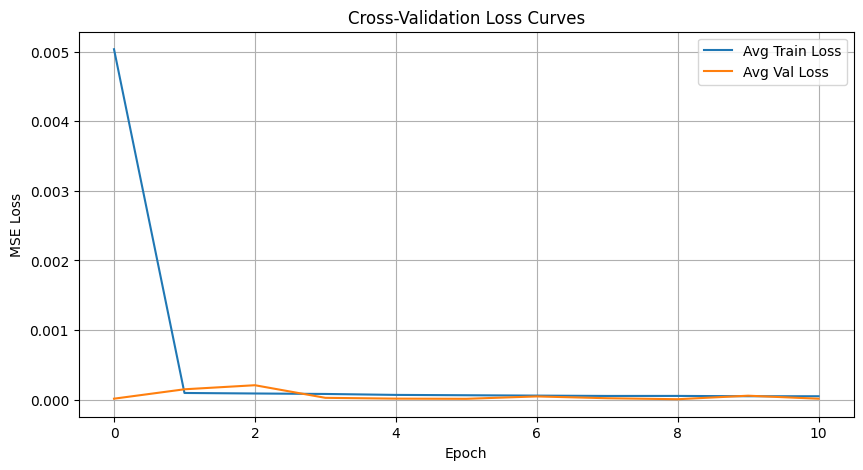

In [ ]:
# Initialize a new model object with the correct input size
model = FeedforwardNet(input_size=3, hidden_layers=5, neurons_per_layer=64).to(device)

# Load the best model's state dictionary into the model
model.load_state_dict(best_model_state_dict)

# Save the model
torch.save(model.state_dict(), "sine_cosine_all_R-C_pairs_model")
print("\n✅ Model saved as 'sine_cosine_all_R-C_pairs_model'")

# Evaluate and visualize the results
plot_avg_loss_curves(train_losses, val_losses)
#evaluate_and_visualize(model, test_set, dataset, device, start=0, window=100)


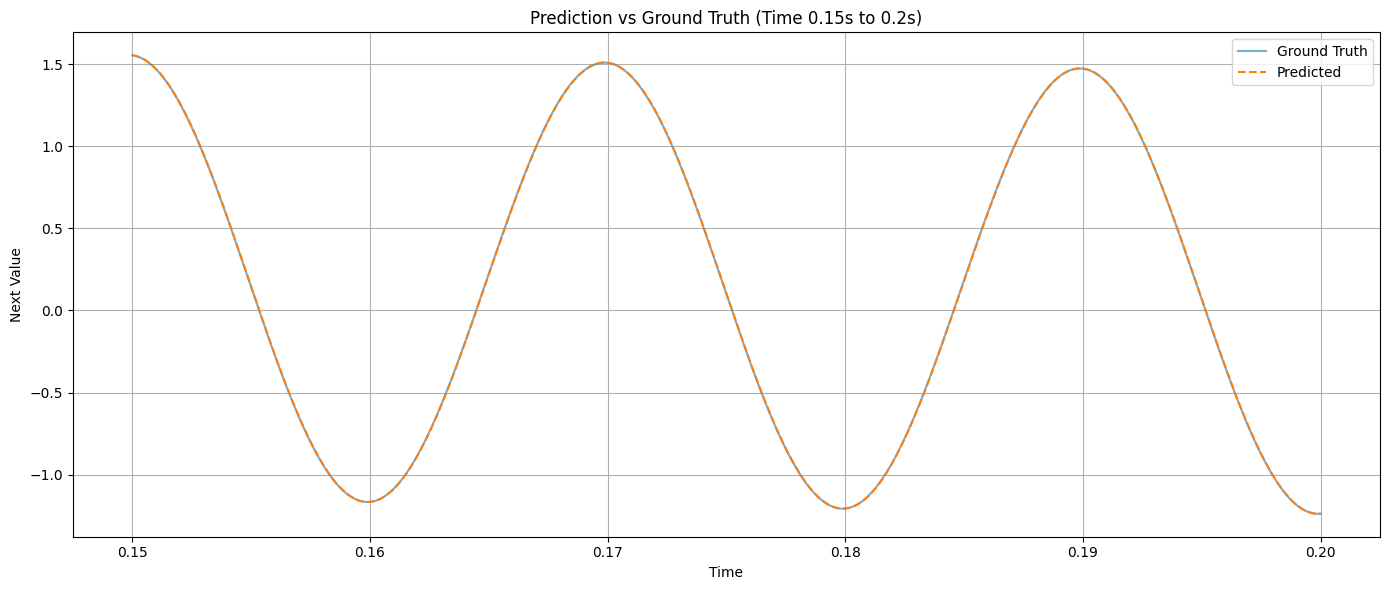

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

# Load your trained model (if not already in memory)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model"))
model.eval()

# Load dataset
df = pd.read_csv("new_data_logger_R80_C0.001_time_step_1e-05.csv")
X_all = df[["time", "value", "next_time"]].values.astype("float32")
y_true_all = df["next_value"].values.astype("float32")
next_time = df["next_time"].values.astype("float32")

# Convert to tensor and predict
X_tensor = torch.tensor(X_all)
with torch.no_grad():
    y_pred_tensor = model(X_tensor).squeeze().cpu().numpy()

# === Custom Time Window ===
start_time = 0.15    # <- change this
end_time = 0.2     # <- and this

# Mask for filtering data in selected time range
mask = (next_time >= start_time) & (next_time <= end_time)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(next_time[mask], y_true_all[mask], label="Ground Truth", alpha=0.6)
plt.plot(next_time[mask], y_pred_tensor[mask], label="Predicted", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Next Value")
plt.title(f"Prediction vs Ground Truth (Time {start_time}s to {end_time}s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


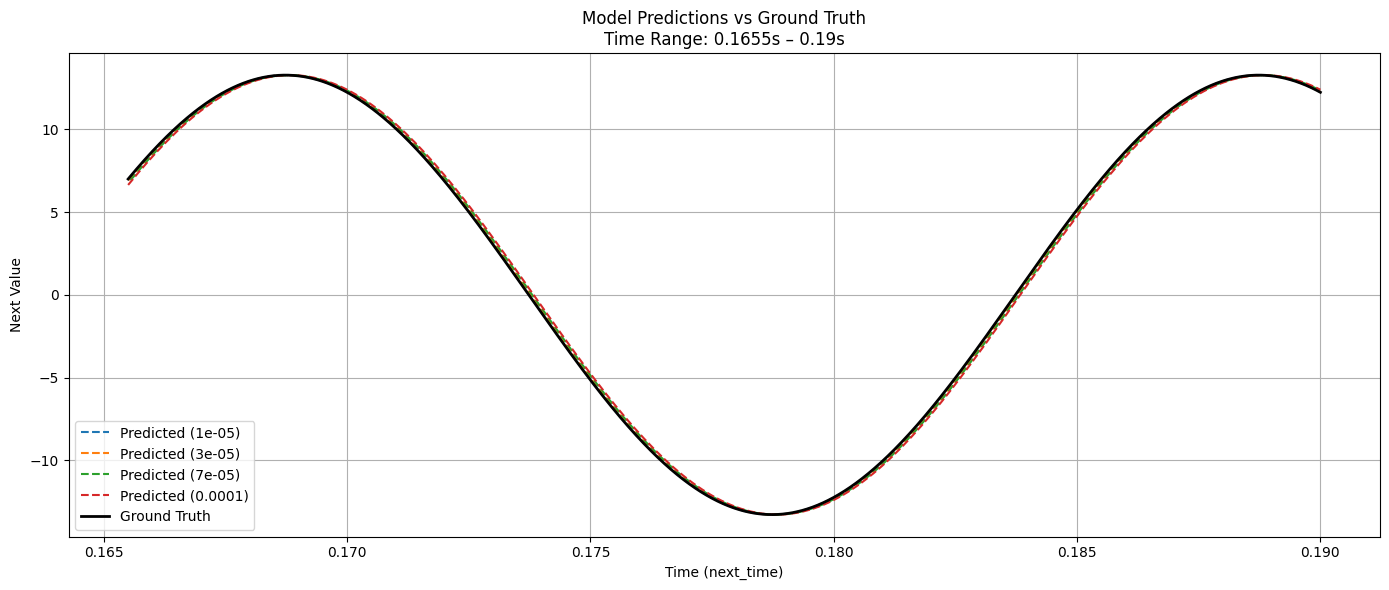

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

# Load your trained model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
# Load your trained model (if not already in memory)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model"))
model.eval()
# Dataset list
df_list = [
    'new_data_logger_R75_C0.0001_time_step_1e-05.csv',
    'new_data_logger_R75_C0.0001_time_step_3e-05.csv',
    'new_data_logger_R75_C0.0001_time_step_7e-05.csv',
    'new_data_logger_R75_C0.0001_time_step_0.0001.csv'
]

# Custom time window
start_time = 0.1655
end_time = 0.19

plt.figure(figsize=(14, 6))

# Plot Ground Truth only once — from a specific, consistent file
ground_truth_df = pd.read_csv("new_data_logger_R75_C0.0001_time_step_1e-05.csv")  # high-res
gt_next_time = ground_truth_df["next_time"].values.astype("float32")
gt_next_value = ground_truth_df["next_value"].values.astype("float32")
gt_mask = (gt_next_time >= start_time) & (gt_next_time <= end_time)



# Loop through each dataset
for f in df_list:
    label = f.split("_time_step_")[-1].replace(".csv", "")  # Extract timestep for legend

    # Load and prepare data
    data_df = pd.read_csv(f)
    X_all = data_df[["time", "value", "next_time"]].values.astype("float32")
    y_true_all = data_df["next_value"].values.astype("float32")
    next_time = data_df["next_time"].values.astype("float32")

    # Predict
    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred_tensor = model(X_tensor).squeeze().cpu().numpy()

    # Apply time window mask
    mask = (next_time >= start_time) & (next_time <= end_time)

    # Plot predictions and ground truth for each file
    plt.plot(next_time[mask], y_pred_tensor[mask], linestyle="--", label=f"Predicted ({label})")
    

plt.plot(gt_next_time[gt_mask], gt_next_value[gt_mask], label="Ground Truth", color="black", linewidth=2)

# Final plot formatting
plt.title(f"Model Predictions vs Ground Truth\nTime Range: {start_time}s – {end_time}s")
plt.xlabel("Time (next_time)")
plt.ylabel("Next Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# === Configuration ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_files = ['new_data_logger_R100_C0.0001_time_step_1e-05.csv', 
             'new_data_logger_R100_C0.001_time_step_1e-05.csv', 'new_data_logger_R100_C1e-05_time_step_1e-05.csv', 
             'new_data_logger_R100_C1e-06_time_step_1e-05.csv', 'new_data_logger_R75_C0.0001_time_step_1e-05.csv', 
             'new_data_logger_R75_C0.001_time_step_1e-05.csv', 'new_data_logger_R75_C1e-05_time_step_1e-05.csv', 
             'new_data_logger_R75_C1e-06_time_step_1e-05.csv', 'new_data_logger_R80_C0.0001_time_step_1e-05.csv', 
             'new_data_logger_R80_C0.001_time_step_1e-05.csv', 'new_data_logger_R80_C1e-05_time_step_1e-05.csv', 
             'new_data_logger_R80_C1e-06_time_step_1e-05.csv', 'new_data_logger_R85_C0.0001_time_step_1e-05.csv', 
             'new_data_logger_R85_C0.001_time_step_1e-05.csv', 'new_data_logger_R85_C1e-05_time_step_1e-05.csv', 
             'new_data_logger_R85_C1e-06_time_step_1e-05.csv', 'new_data_logger_R90_C0.0001_time_step_1e-05.csv', 
             'new_data_logger_R90_C0.001_time_step_1e-05.csv', 'new_data_logger_R90_C1e-05_time_step_1e-05.csv', 
             'new_data_logger_R90_C1e-06_time_step_1e-05.csv', 'new_data_logger_R95_C0.0001_time_step_1e-05.csv', 
             'new_data_logger_R95_C0.001_time_step_1e-05.csv', 'new_data_logger_R95_C1e-05_time_step_1e-05.csv', 
             'new_data_logger_R95_C1e-06_time_step_1e-05.csv']

dataset = TimeSeriesDataset(csv_files)

hidden_layer_options = [5, 9, 13]
width_options = [32, 48, 64]
results = []

# === Training and Evaluation Loop ===
for hidden_layers in hidden_layer_options:
    for neurons_per_layer in width_options:
        print(f"🚀 Training model with {hidden_layers} layers and {neurons_per_layer} neurons/layer")
        
        model, test_set, train_losses, val_losses = cross_validate(dataset, hidden_layers, neurons_per_layer)
        
        # Save state_dict
        model_path = f"model_L{hidden_layers}_W{neurons_per_layer}_RC_pairs.pth"
        torch.save(model, model_path)


        # Recreate model with correct architecture for loading
        model_loaded = FeedforwardNet(input_size=3, hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer)
        model_loaded.load_state_dict(torch.load(model_path))
        model_loaded.eval()

        # Evaluate
        test_loader = torch.utils.data.DataLoader(test_set, batch_size=len(test_set), shuffle=False)
        x_test, y_test = next(iter(test_loader))

        with torch.no_grad():
            y_pred = model_loaded(x_test).squeeze().cpu().numpy()
        y_true = y_test.numpy()
        mse = mean_squared_error(y_true, y_pred)

        results.append({
            "layers": hidden_layers,
            "width": neurons_per_layer,
            "mse": mse,
            "next_time": x_test[:, 2].numpy(),  # Assuming column 2 is next_time
            "true": y_true,
            "pred": y_pred
        })


In [ ]:
# === Define time window ===
start_time = 0.15
end_time = 0.16

# === Sort and Pick Top 5 ===
top_models = sorted(results, key=lambda r: r["mse"])[:5]

# === Create Plot ===
plt.figure(figsize=(14, 6))

# === Ground Truth (with time mask and downsampling) ===
next_time = top_models[0]["next_time"]
y_true = top_models[0]["true"]

# Apply mask
mask = (next_time >= start_time) & (next_time <= end_time)
masked_time = next_time[mask]
masked_true = y_true[mask]

# Sort and downsample
idx_sorted = np.argsort(masked_time)
downsampled_idx = idx_sorted[::10]

plt.plot(
    masked_time[downsampled_idx],
    masked_true[downsampled_idx],
    label="Ground Truth",
    color="black",
    linewidth=2,
    alpha=0.8,
)

# === Model Predictions (masked + downsampled) ===
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
for i, r in enumerate(top_models):
    next_time = r["next_time"]
    pred = r["pred"]

    mask = (next_time >= start_time) & (next_time <= end_time)
    masked_time = next_time[mask]
    masked_pred = pred[mask]

    idx_sorted = np.argsort(masked_time)
    downsampled_idx = idx_sorted[::10]

    label = f"L{r['layers']}_W{r['width']} | MSE={r['mse']:.2e}"
    
    plt.plot(
        masked_time[downsampled_idx],
        masked_pred[downsampled_idx],
        label=label,
        linestyle="--",
        color=colors[i % len(colors)],
        alpha=0.9
    )

# === Final Touches ===
plt.title(f"Top 5 Model Predictions vs Ground Truth (Time {start_time}s to {end_time}s)")
plt.xlabel("Time (next_time)")
plt.ylabel("Next Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [91]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import numpy as np

# === Sort and Pick Top 5 ===
top_models = sorted(results, key=lambda r: r["mse"])[:5]

# === Subplot Layout (1 row per model) ===
fig = make_subplots(
    rows=5, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    subplot_titles=[f"L{r['layers']}_W{r['width']} | MSE={r['mse']:.2e}" for r in top_models]
)

# === Add traces ===
for i, r in enumerate(top_models):
    idx = np.argsort(r["next_time"])
    t = r["next_time"][idx]
    y_true = r["true"][idx]
    y_pred = r["pred"][idx]

    fig.add_trace(go.Scatter(x=t, y=y_true, mode="lines", name="Ground Truth",
                             line=dict(color="black", width=2), showlegend=(i == 0)),
                  row=i+1, col=1)

    fig.add_trace(go.Scatter(x=t, y=y_pred, mode="lines", name="Predicted",
                             line=dict(dash="dash", width=2), showlegend=(i == 0)),
                  row=i+1, col=1)

# === Layout ===
fig.update_layout(
    height=1200,
    title_text="Top 5 Model Predictions vs Ground Truth (Interactive)",
    hovermode="x unified",
    legend=dict(y=1.02, orientation="h"),
    margin=dict(t=100),
)

fig.update_xaxes(title_text="Time (next_time)", row=5, col=1)
fig.update_yaxes(title_text="Next Value")

fig.write_html("top5_models_plot_R-C_pairs.html")

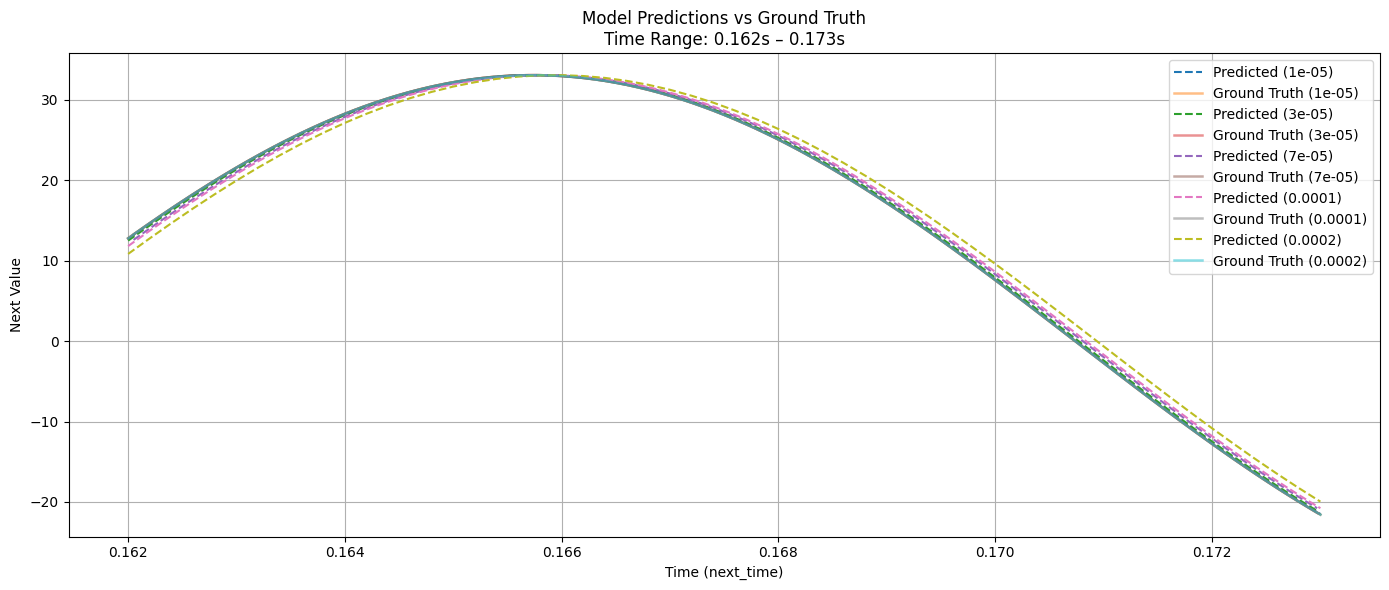

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

# Load your trained model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model"))
model.eval()

# Dataset list
df_list = [
    'new_data_logger_R75_C1e-05_time_step_1e-05.csv',
    'new_data_logger_R75_C1e-05_time_step_3e-05.csv',
    'new_data_logger_R75_C1e-05_time_step_7e-05.csv',
    'new_data_logger_R75_C1e-05_time_step_0.0001.csv',
    'new_data_logger_R75_C1e-05_time_step_0.0002.csv'
]

# Custom time window
start_time = 0.162
end_time = 0.173

# Plot init
plt.figure(figsize=(14, 6))

# Loop through each dataset and plot both prediction and corresponding ground truth
for f in df_list:
    
    label = f.split("_time_step_")[-1].replace(".csv", "")  # Extract timestep for legend

    # Load data
    data_df = pd.read_csv(f)
    X_all = data_df[["time", "value", "next_time"]].values.astype("float32")
    y_true_all = data_df["next_value"].values.astype("float32")
    next_time = data_df["next_time"].values.astype("float32")

    # Predict
    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred_tensor = model(X_tensor).squeeze().cpu().numpy()

    # Apply time mask
    mask = (next_time >= start_time) & (next_time <= end_time)

    # Plot predictions
    plt.plot(next_time[mask], y_pred_tensor[mask], linestyle="--", label=f"Predicted ({label})")

    # Plot matching ground truth from the same file
    plt.plot(next_time[mask], y_true_all[mask], alpha=0.5, linewidth=1.8, label=f"Ground Truth ({label})")
    #plt.show()

# Final touches
plt.title(f"Model Predictions vs Ground Truth\nTime Range: {start_time}s – {end_time}s")
plt.xlabel("Time (next_time)")
plt.ylabel("Next Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model.pth"))
model.eval()

# Dataset list
# Datasets
# Dataset list
df_list = [
    'new_data_logger_R75_C1e-05_time_step_1e-05.csv',
    'new_data_logger_R75_C1e-05_time_step_3e-05.csv',
    'new_data_logger_R75_C1e-05_time_step_7e-05.csv',
    'new_data_logger_R75_C1e-05_time_step_0.0001.csv',
    'new_data_logger_R75_C1e-05_time_step_0.0002.csv'
]

start_time = 0.157
end_time = 0.21

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    X_all = df[["time", "value", "next_time"]].values.astype("float32")
    y_true = df["next_value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R(?P<R>\d+)_C(?P<C>[\d.eE+-]+)", df_list[0])
R_val, C_val = (match.group("R"), match.group("C")) if match else ("?", "?")

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'R{R_val}R{C_val}_R-C_pairs.png', dpi=300)

# Then display it
plt.show()



RuntimeError: Error(s) in loading state_dict for FeedforwardNet:
	Missing key(s) in state_dict: "model.1.alpha", "model.3.alpha", "model.5.alpha", "model.7.alpha", "model.9.alpha". 

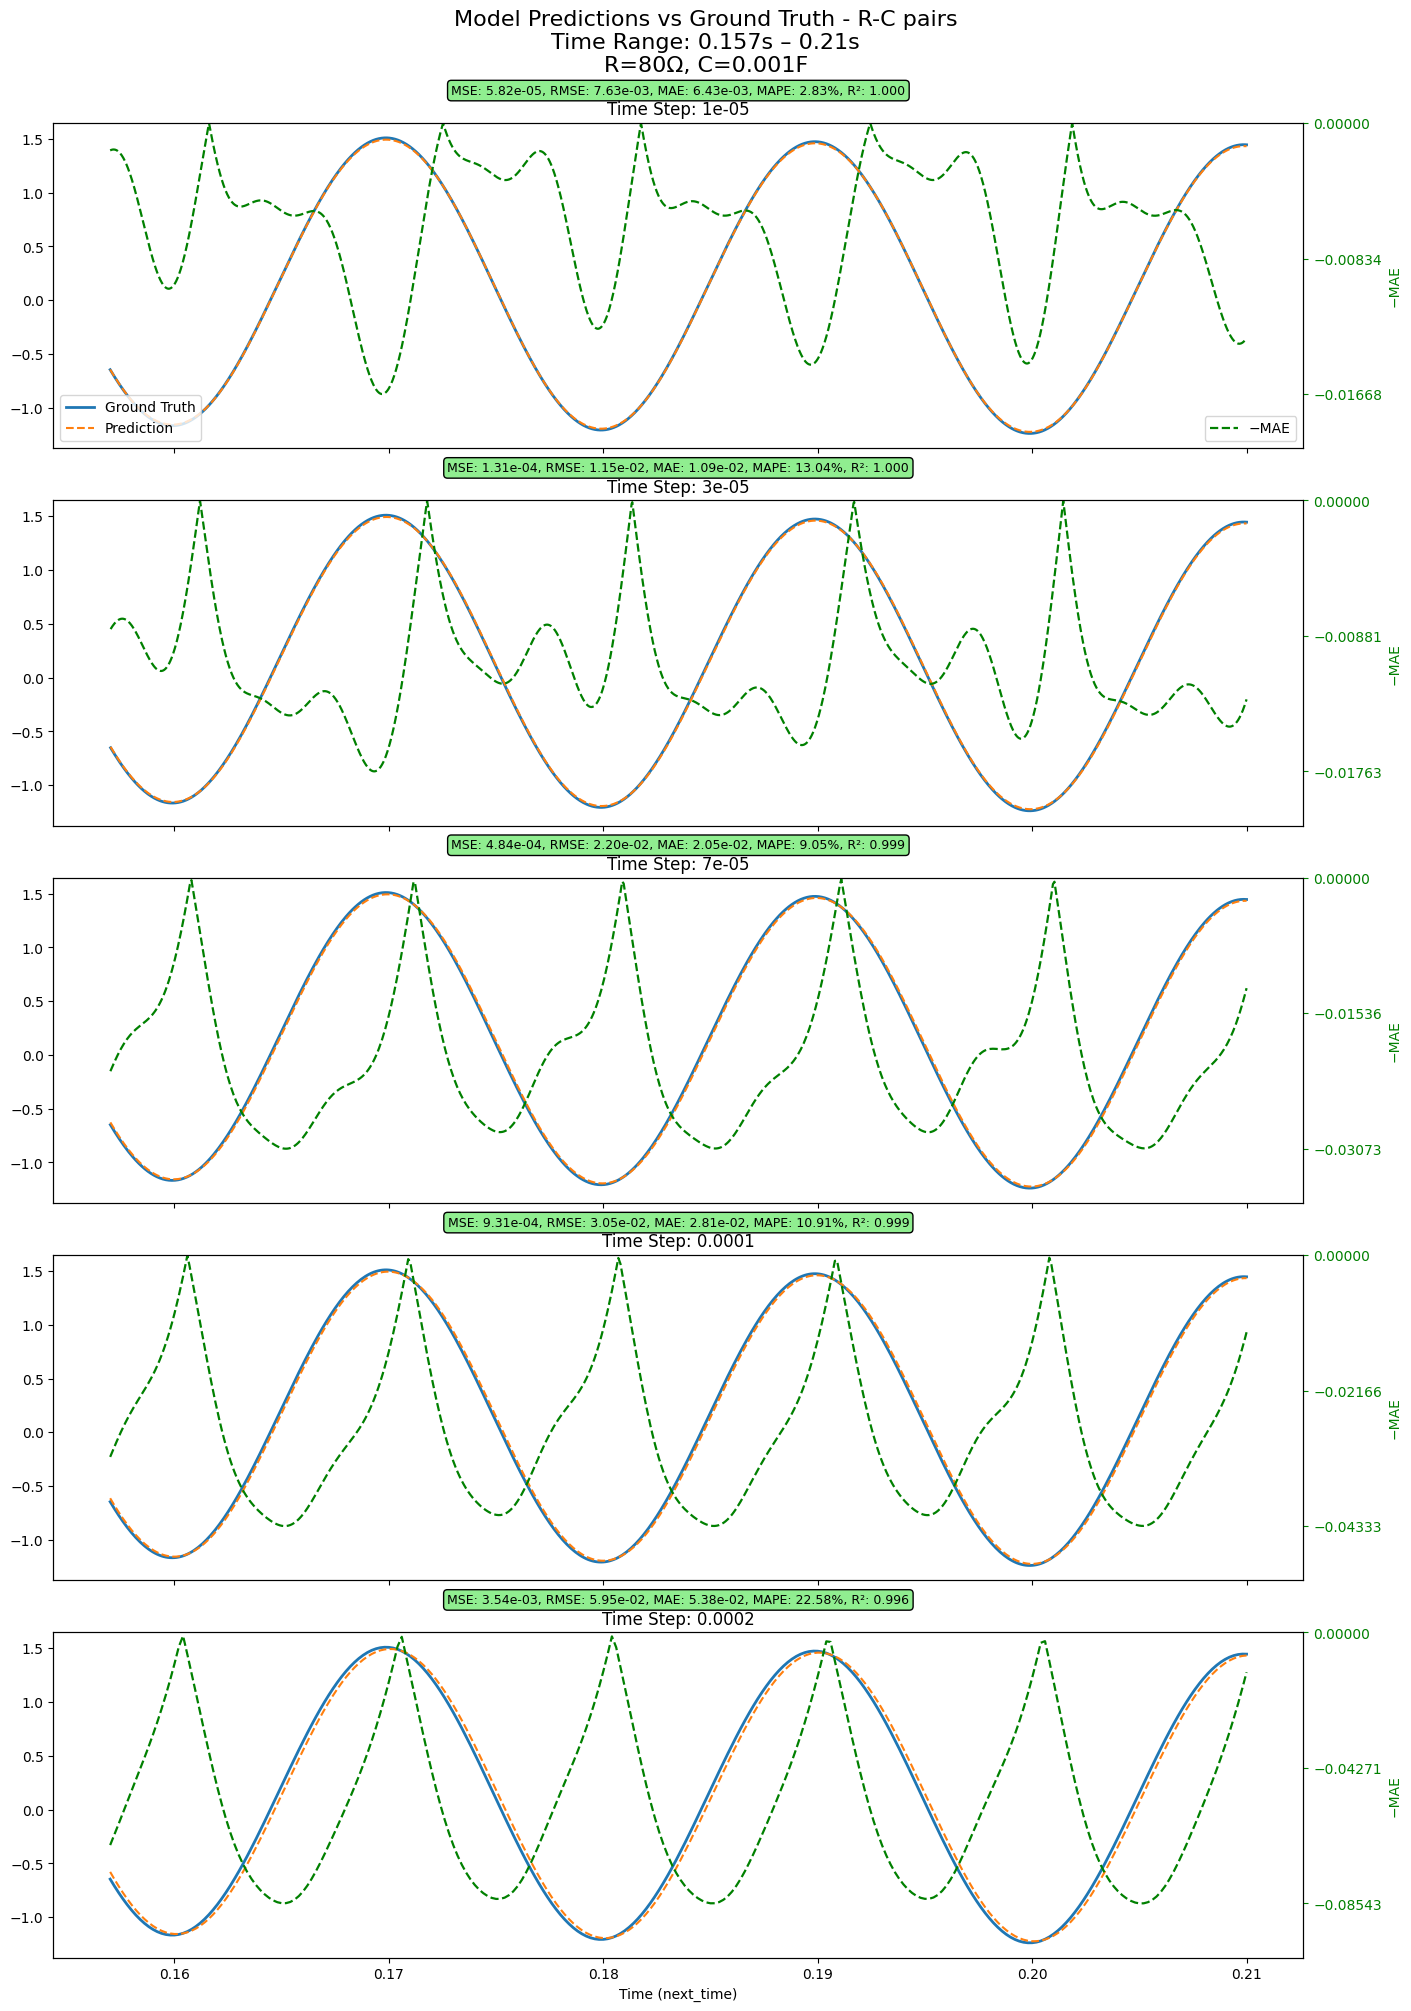

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model.pth"))
model.eval()

# Dataset list
# Datasets
df_list = [
    'new_data_logger_R80_C0.001_time_step_1e-05.csv',
    'new_data_logger_R80_C0.001_time_step_3e-05.csv',
    'new_data_logger_R80_C0.001_time_step_7e-05.csv',
    'new_data_logger_R80_C0.001_time_step_0.0001.csv',
    'new_data_logger_R80_C0.001_time_step_0.0002.csv',
]

start_time = 0.157
end_time = 0.21

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    X_all = df[["time", "value", "next_time"]].values.astype("float32")
    y_true = df["next_value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R(?P<R>\d+)_C(?P<C>[\d.eE+-]+)", df_list[0])
R_val, C_val = (match.group("R"), match.group("C")) if match else ("?", "?")

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'R{R_val}R{C_val}_R-C_pairs.png', dpi=300)

# Then display it
plt.show()


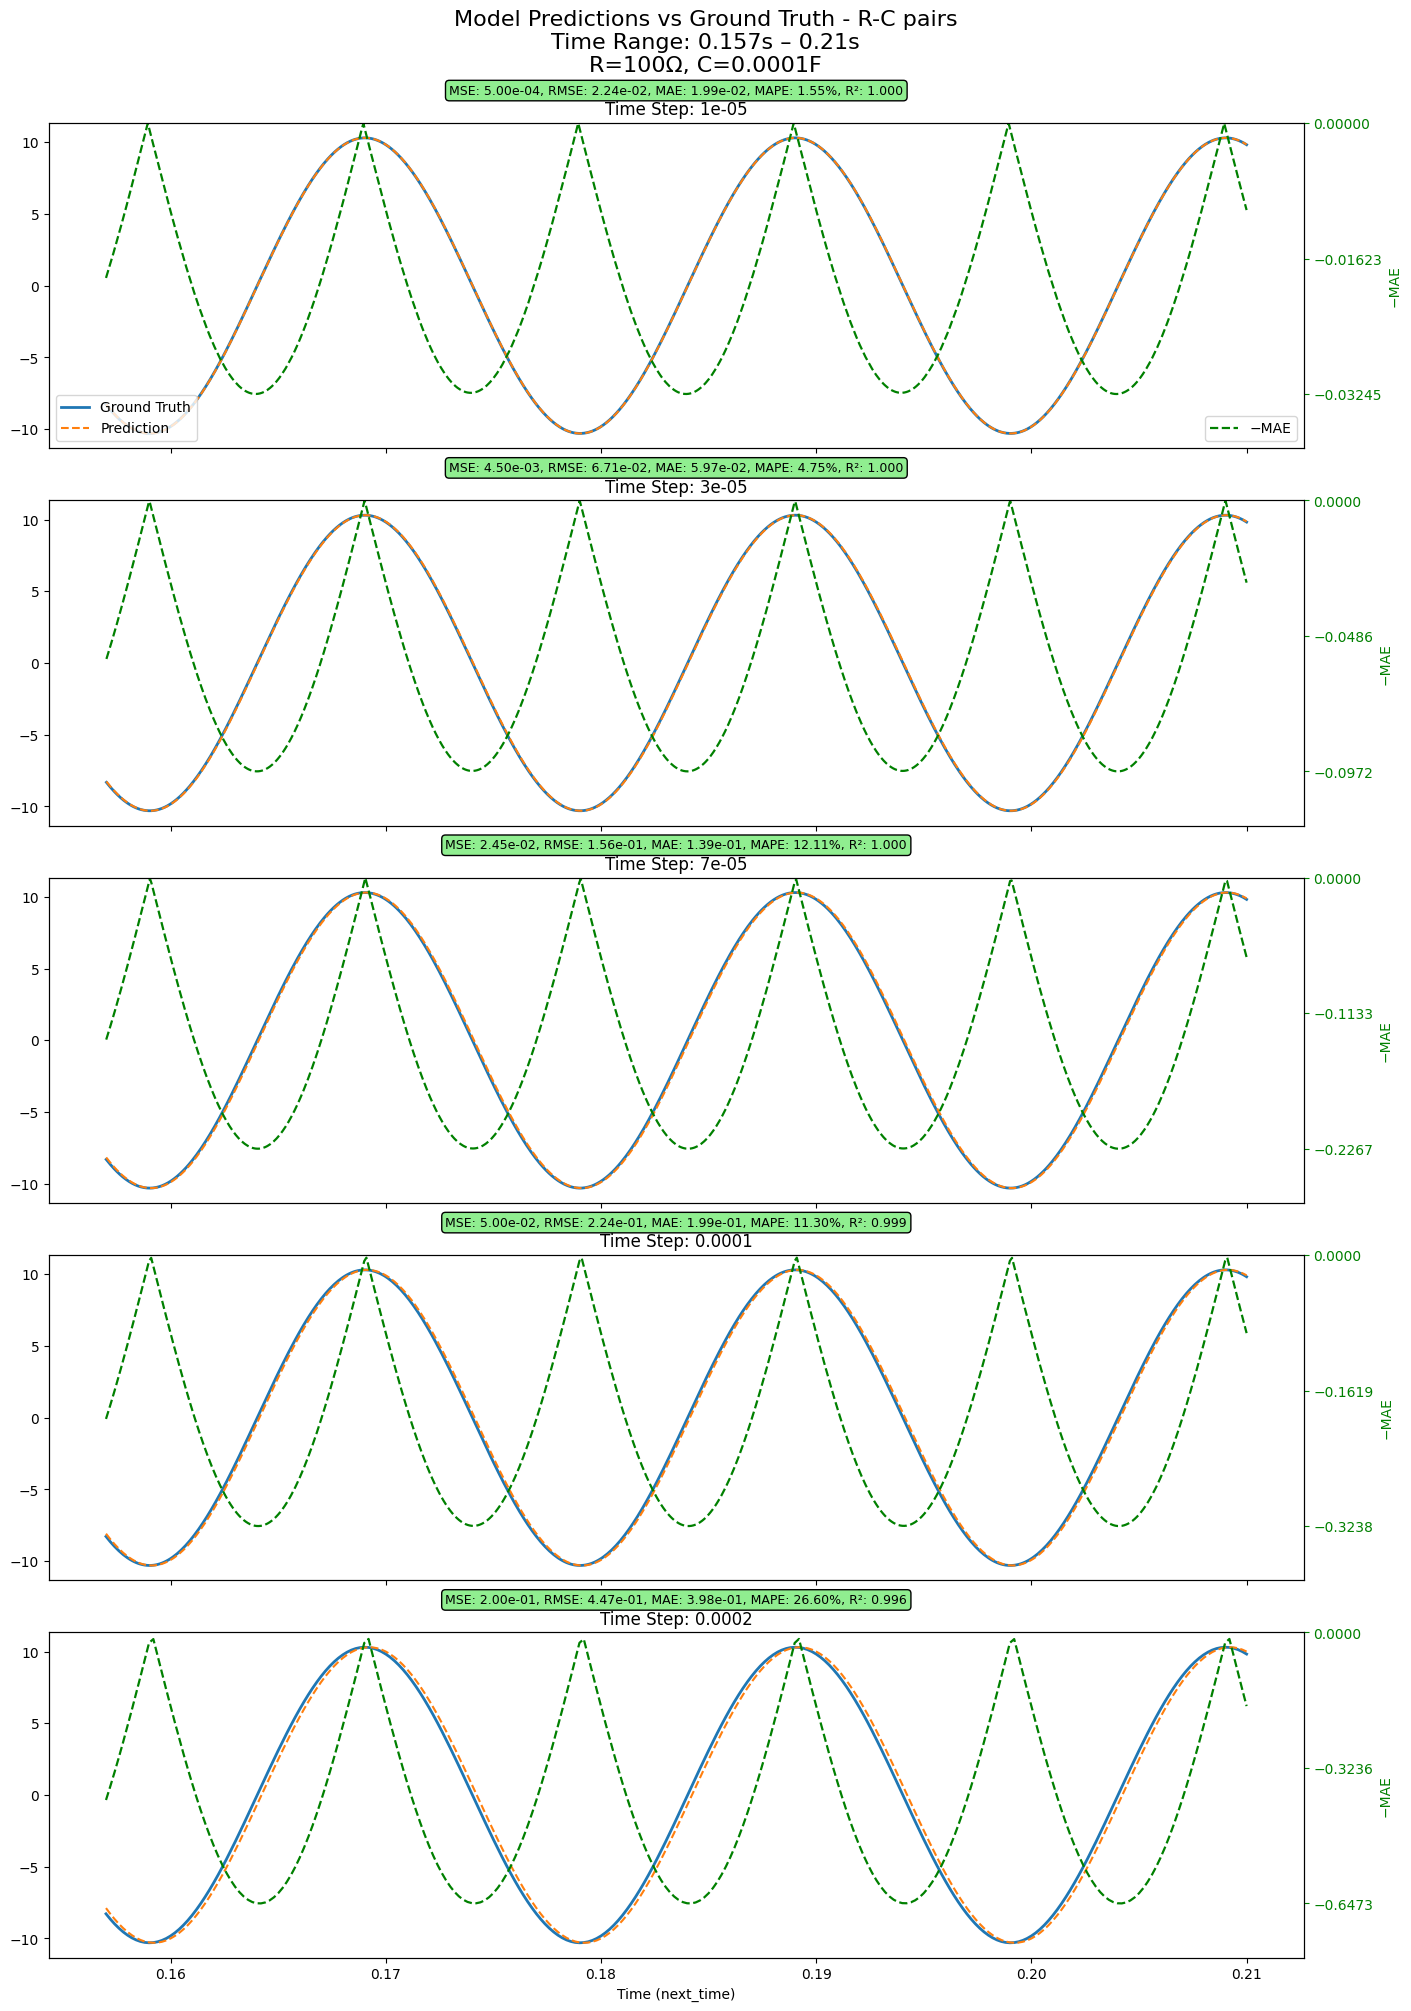

In [19]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model.pth"))
model.eval()

# Dataset list
df_list = [
    'new_data_logger_R100_C0.0001_time_step_1e-05.csv',
    'new_data_logger_R100_C0.0001_time_step_3e-05.csv',
    'new_data_logger_R100_C0.0001_time_step_7e-05.csv',
    'new_data_logger_R100_C0.0001_time_step_0.0001.csv',
    'new_data_logger_R100_C0.0001_time_step_0.0002.csv',
]


start_time = 0.157
end_time = 0.21

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    X_all = df[["time", "value", "next_time"]].values.astype("float32")
    y_true = df["next_value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R(?P<R>\d+)_C(?P<C>[\d.eE+-]+)", df_list[0])
R_val, C_val = (match.group("R"), match.group("C")) if match else ("?", "?")

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'R{R_val}R{C_val}_R-C_pairs.png', dpi=300)

# Then display it
plt.show()


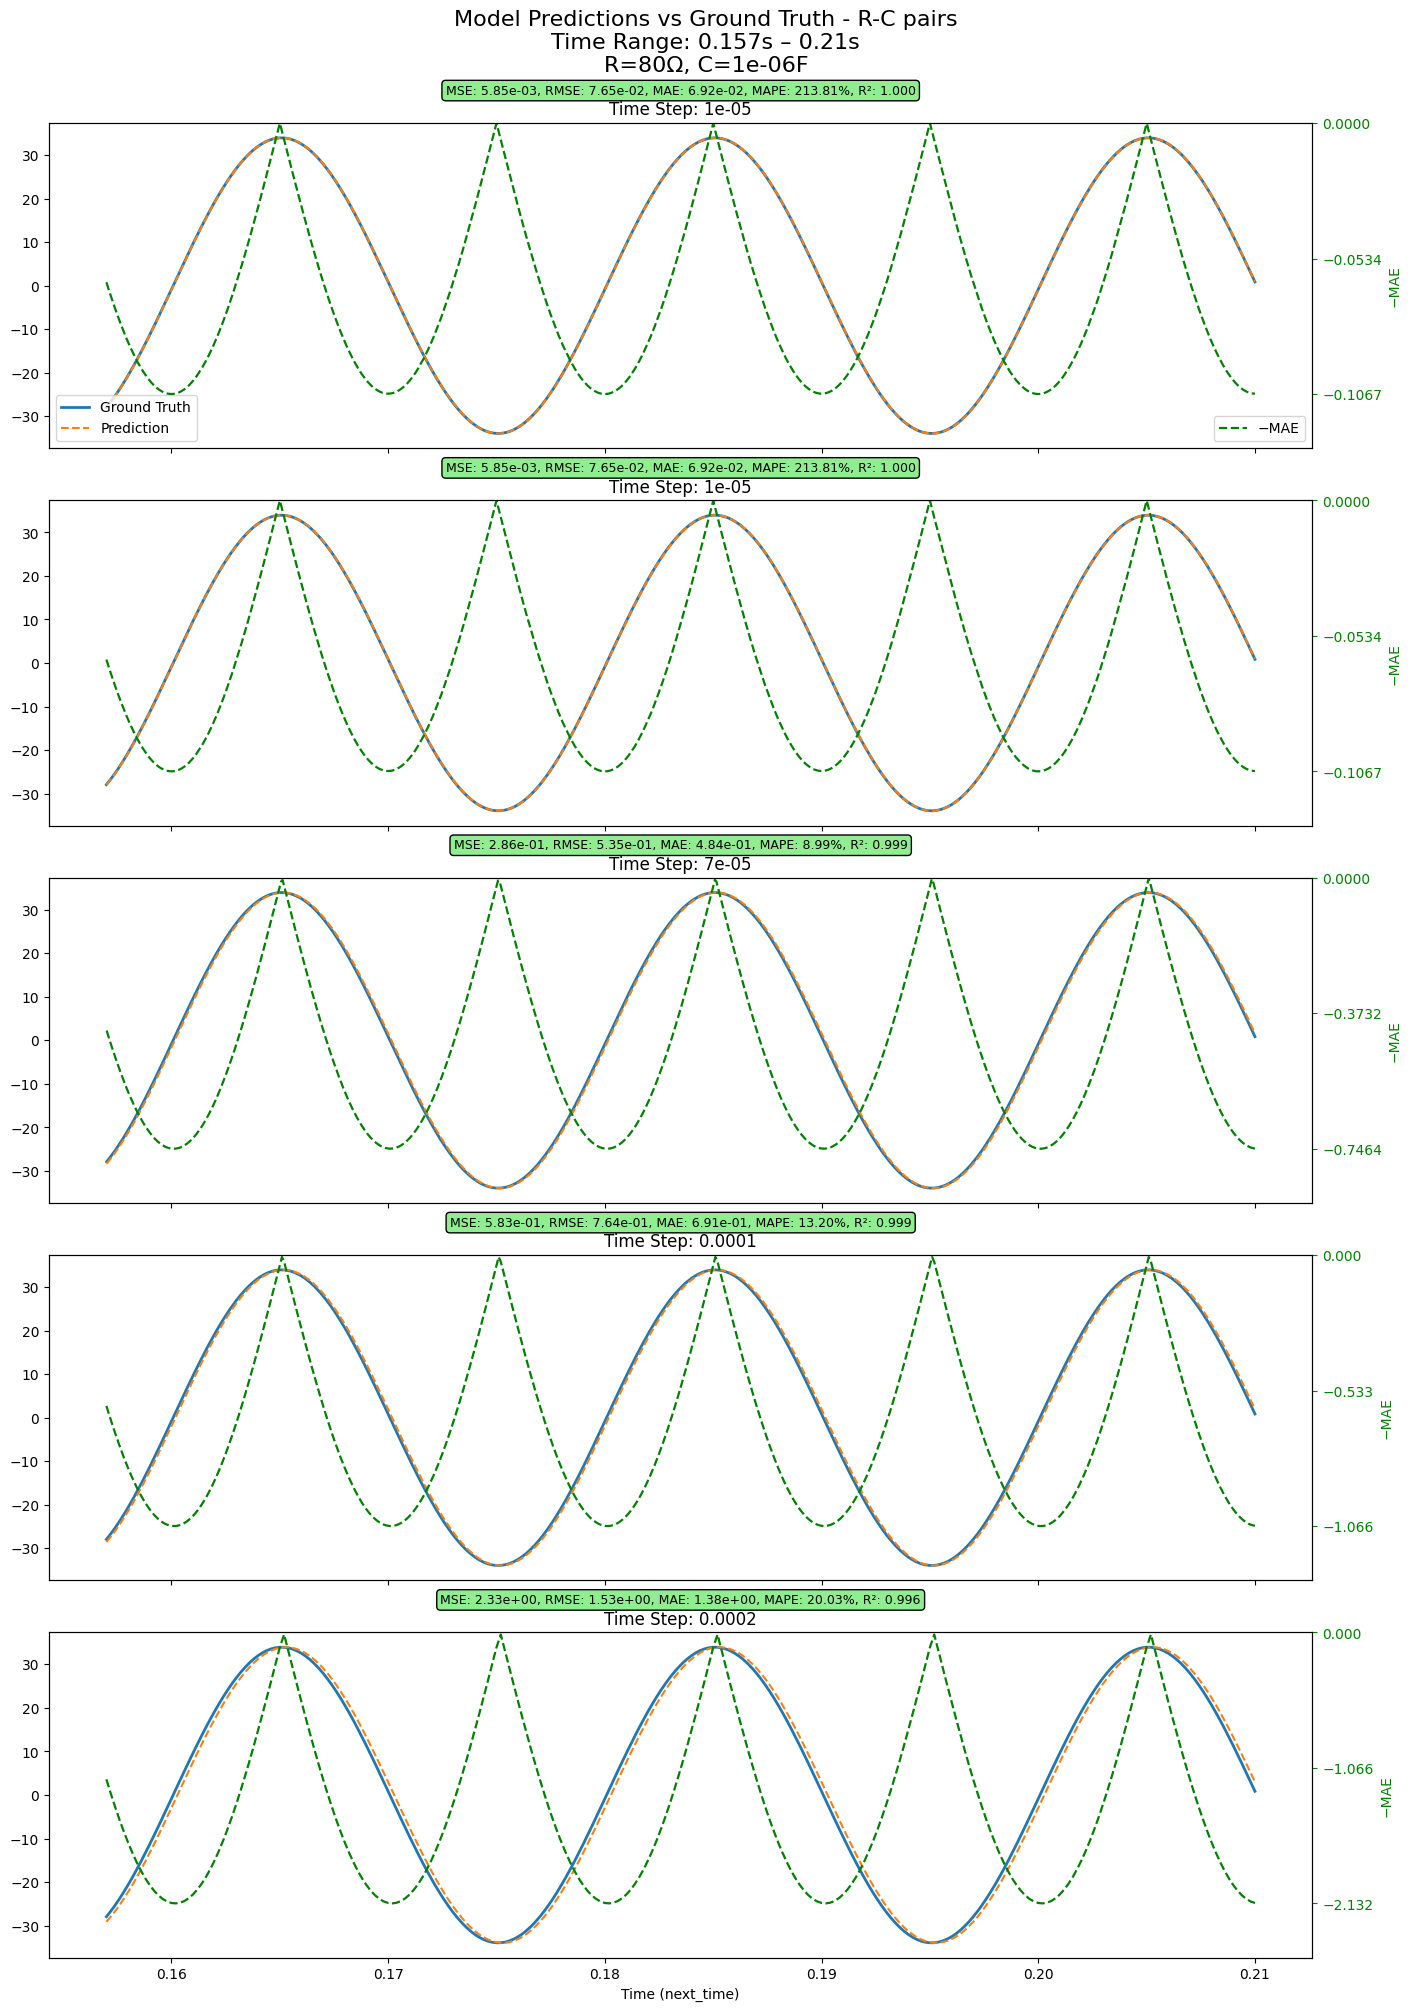

In [20]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model.pth"))
model.eval()

# Dataset list
df_list = [
    'new_data_logger_R80_C1e-06_time_step_1e-05.csv',
    'new_data_logger_R80_C1e-06_time_step_1e-05.csv',
    'new_data_logger_R80_C1e-06_time_step_7e-05.csv',
    'new_data_logger_R80_C1e-06_time_step_0.0001.csv',
    'new_data_logger_R80_C1e-06_time_step_0.0002.csv',
]


start_time = 0.157
end_time = 0.21

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    X_all = df[["time", "value", "next_time"]].values.astype("float32")
    y_true = df["next_value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R(?P<R>\d+)_C(?P<C>[\d.eE+-]+)", df_list[0])
R_val, C_val = (match.group("R"), match.group("C")) if match else ("?", "?")

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'R{R_val}R{C_val}_R-C_pairs.png', dpi=300)

# Then display it
plt.show()

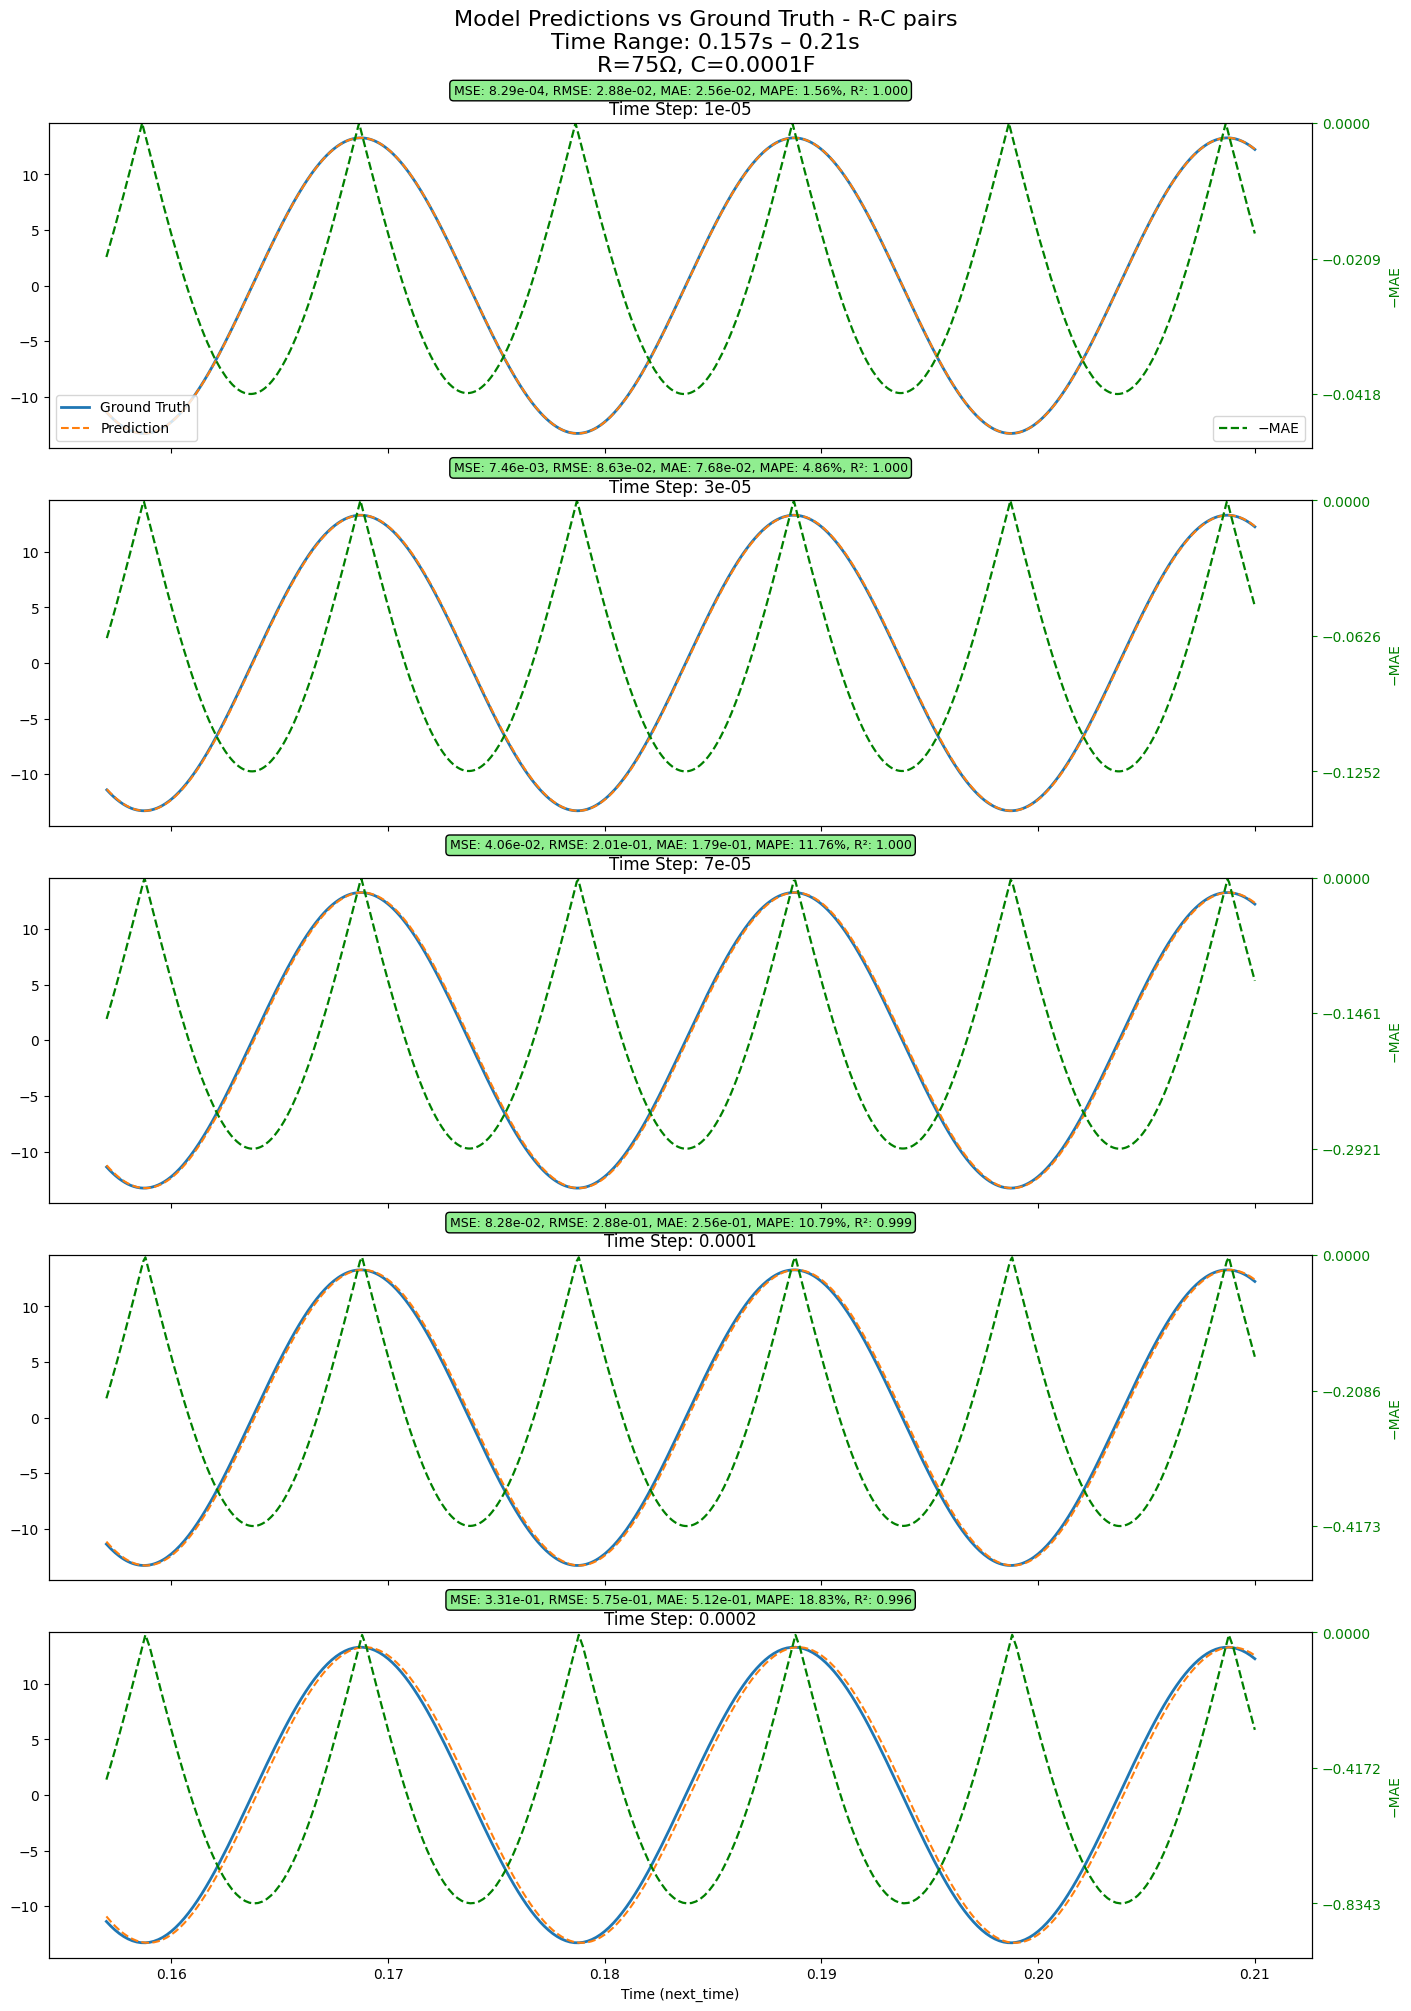

In [21]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model.pth"))
model.eval()

# Dataset list
df_list = [
    'new_data_logger_R75_C0.0001_time_step_1e-05.csv',
    'new_data_logger_R75_C0.0001_time_step_3e-05.csv',
    'new_data_logger_R75_C0.0001_time_step_7e-05.csv',
    'new_data_logger_R75_C0.0001_time_step_0.0001.csv',
    'new_data_logger_R75_C0.0001_time_step_0.0002.csv',
]


start_time = 0.157
end_time = 0.21

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    X_all = df[["time", "value", "next_time"]].values.astype("float32")
    y_true = df["next_value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R(?P<R>\d+)_C(?P<C>[\d.eE+-]+)", df_list[0])
R_val, C_val = (match.group("R"), match.group("C")) if match else ("?", "?")

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'R{R_val}R{C_val}_R-C_pairs.png', dpi=300)

# Then display it
plt.show()

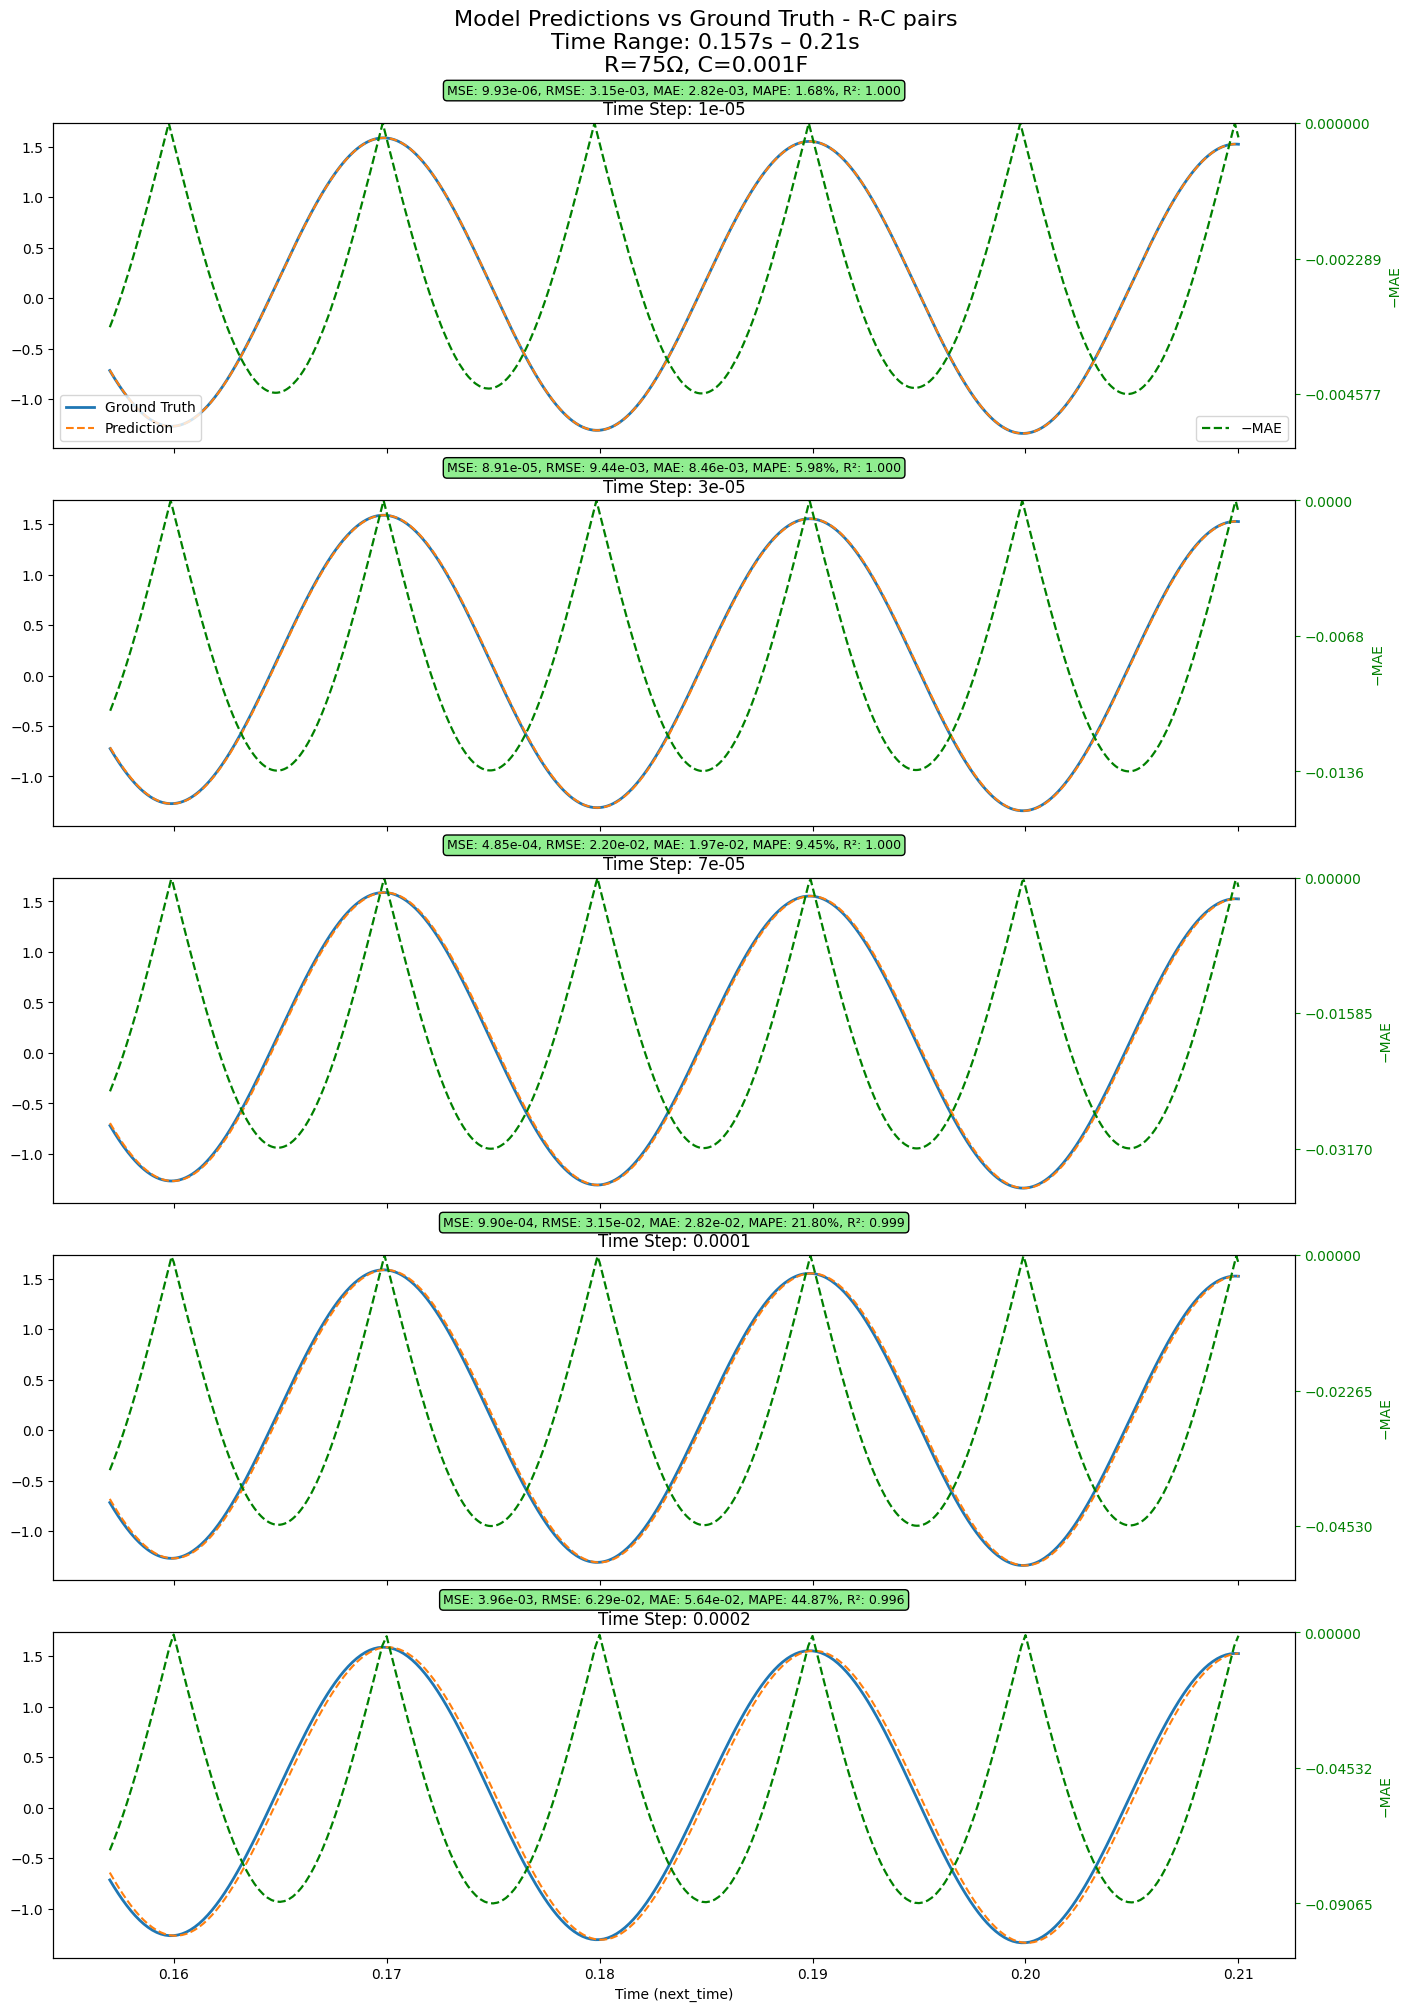

In [22]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model.pth"))
model.eval()

# Dataset list
df_list = [
    'new_data_logger_R75_C0.001_time_step_1e-05.csv',
    'new_data_logger_R75_C0.001_time_step_3e-05.csv',
    'new_data_logger_R75_C0.001_time_step_7e-05.csv',
    'new_data_logger_R75_C0.001_time_step_0.0001.csv',
    'new_data_logger_R75_C0.001_time_step_0.0002.csv',
]


start_time = 0.157
end_time = 0.21

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    X_all = df[["time", "value", "next_time"]].values.astype("float32")
    y_true = df["next_value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R(?P<R>\d+)_C(?P<C>[\d.eE+-]+)", df_list[0])
R_val, C_val = (match.group("R"), match.group("C")) if match else ("?", "?")

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'R{R_val}R{C_val}_R-C_pairs.png', dpi=300)

# Then display it
plt.show()

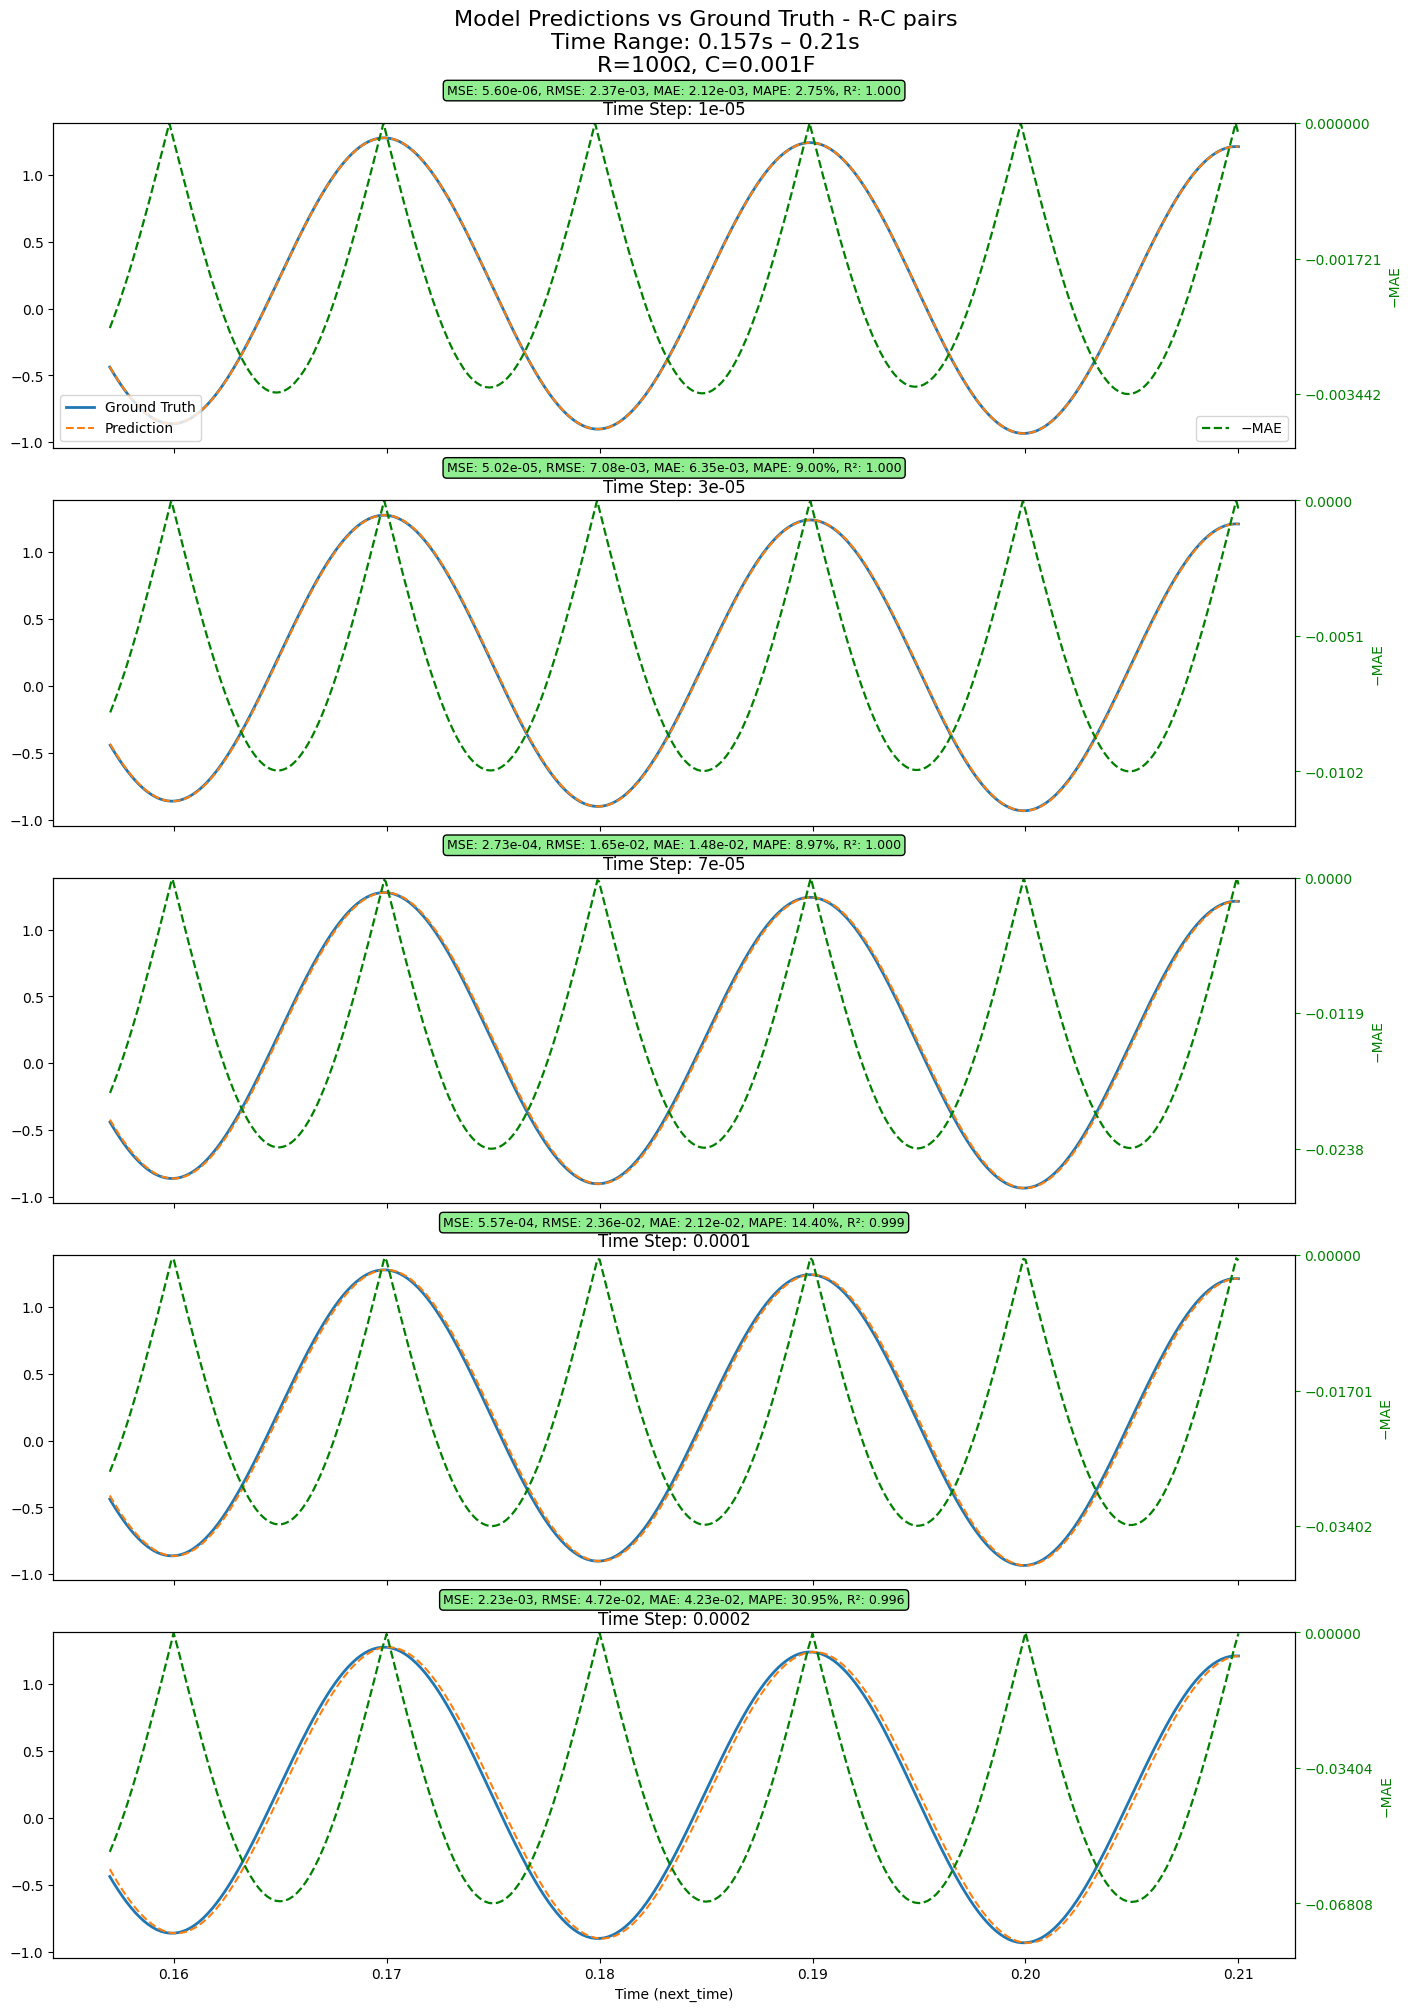

In [23]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model.pth"))
model.eval()

# Dataset list
df_list = [
    'new_data_logger_R100_C0.001_time_step_1e-05.csv',
    'new_data_logger_R100_C0.001_time_step_3e-05.csv',
    'new_data_logger_R100_C0.001_time_step_7e-05.csv',
    'new_data_logger_R100_C0.001_time_step_0.0001.csv',
    'new_data_logger_R100_C0.001_time_step_0.0002.csv',
]


start_time = 0.157
end_time = 0.21

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    X_all = df[["time", "value", "next_time"]].values.astype("float32")
    y_true = df["next_value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R(?P<R>\d+)_C(?P<C>[\d.eE+-]+)", df_list[0])
R_val, C_val = (match.group("R"), match.group("C")) if match else ("?", "?")

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'R{R_val}R{C_val}_R-C_pairs.png', dpi=300)

# Then display it
plt.show()

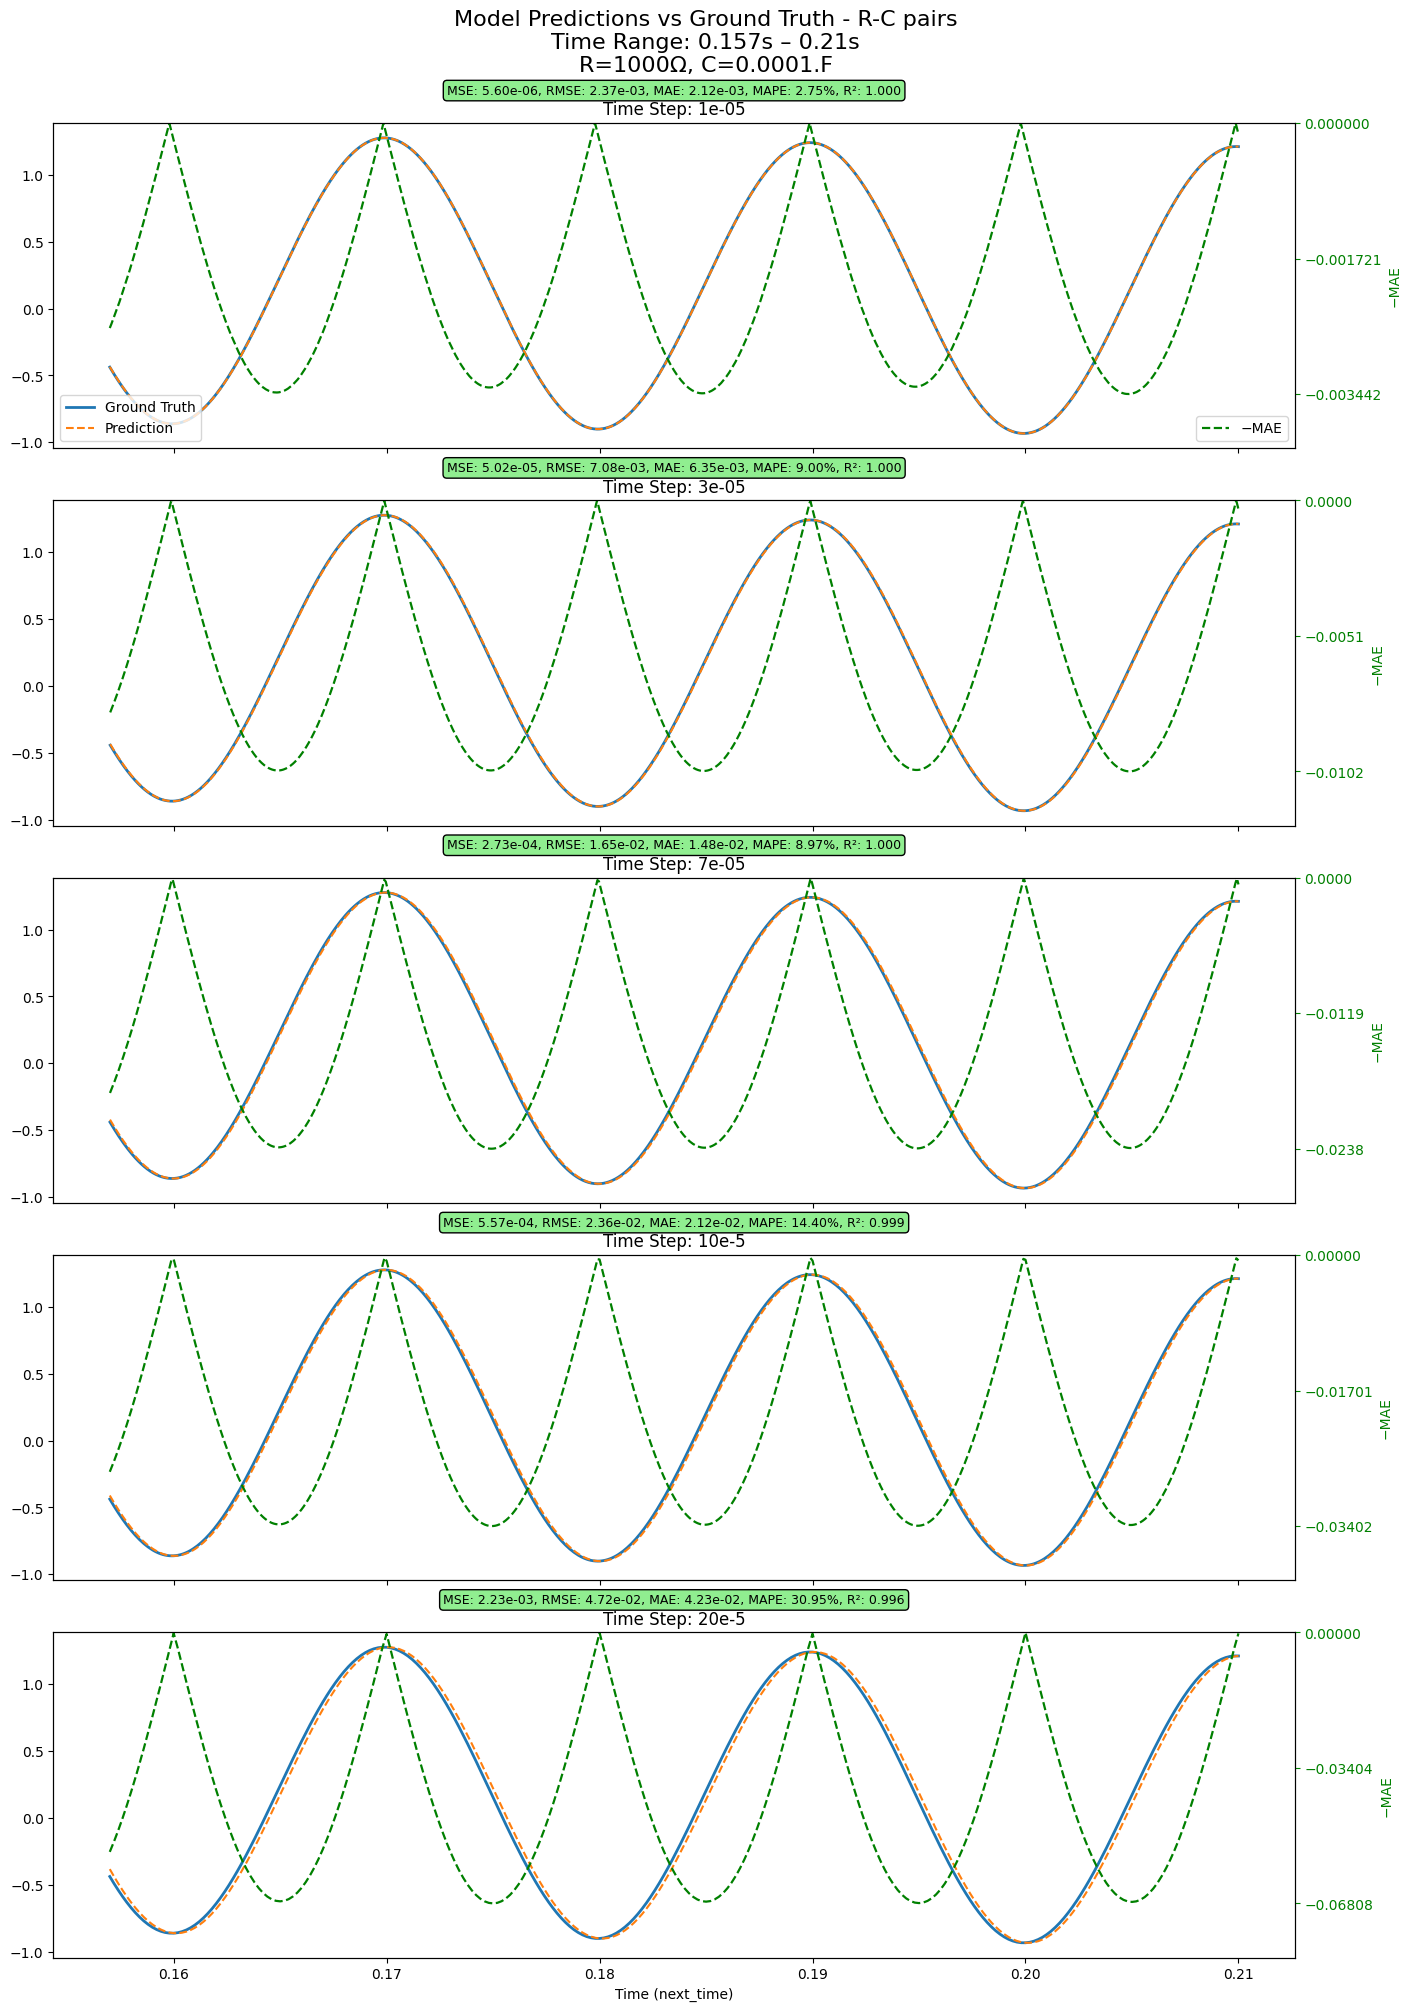

In [24]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=5, neurons_per_layer=64, input_size=3, output_size=1)
model.load_state_dict(torch.load("sine_cosine_all_R-C_pairs_model.pth"))
model.eval()

# Dataset list
df_list = [
    'filtered_modified_data_logger_R1000_C0.0001.csv_time_step_1e-05.csv',
    'filtered_modified_data_logger_R1000_C0.0001.csv_time_step_3e-05.csv',
    'filtered_modified_data_logger_R1000_C0.0001.csv_time_step_7e-05.csv',
    'filtered_modified_data_logger_R1000_C0.0001.csv_time_step_10e-5.csv',
    'filtered_modified_data_logger_R1000_C0.0001.csv_time_step_20e-5.csv',
]


start_time = 0.157
end_time = 0.21

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    X_all = df[["time", "value", "next_time"]].values.astype("float32")
    y_true = df["next_value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R(?P<R>\d+)_C(?P<C>[\d.eE+-]+)", df_list[0])
R_val, C_val = (match.group("R"), match.group("C")) if match else ("?", "?")

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'R{R_val}R{C_val}_R-C_pairs.png', dpi=300)

# Then display it
plt.show()